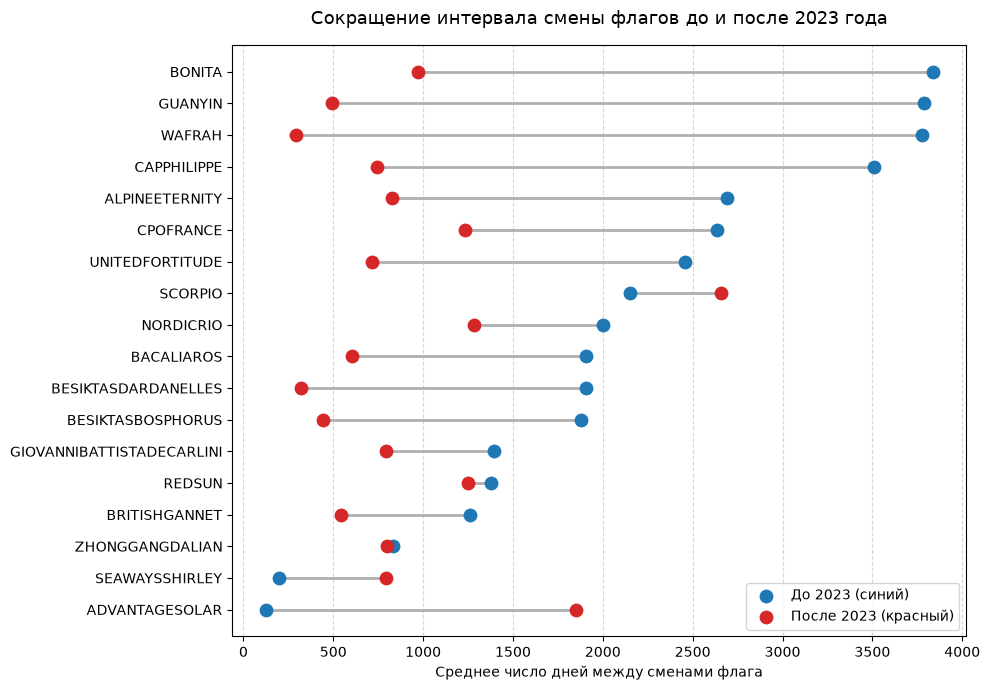

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
summary_df = pd.read_csv('../data/vessel_summary.csv')
cmp_df = pd.read_csv('../data/flag_change_intervals.csv')
identities_df = pd.read_csv('../data/identities.csv')

# 1. Подтягиваем имена судов для оси Y
plot_df = cmp_df.merge(summary_df[['imo', 'current_name']], on='imo').sort_values('before', ascending=True).reset_index(drop=True)

# 2. Отрисовка
fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(plot_df))

# Линии между точками (дельта)
for i in y_pos:
    ax.plot([plot_df.loc[i, 'before'], plot_df.loc[i, 'after']], [i, i], color='#b0b0b0', linewidth=2, zorder=1)

# Точки
ax.scatter(plot_df['before'], y_pos, color='#1f77b4', s=80, label='До 2023 (синий)', zorder=2)
ax.scatter(plot_df['after'], y_pos, color='#d62728', s=80, label='После 2023 (красный)', zorder=2)

# Оформление
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['current_name'])
ax.set_xlabel('Среднее число дней между сменами флага')
ax.set_title('Сокращение интервала смены флагов до и после 2023 года', fontsize=13, pad=15)
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

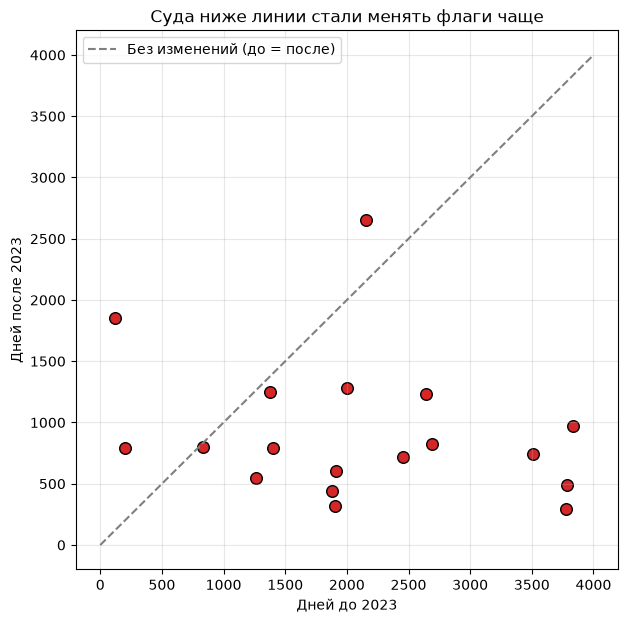

In [5]:
plt.figure(figsize=(7, 7))
plt.scatter(cmp_df['before'], cmp_df['after'], color='#d62728', edgecolors='black', s=70)
plt.plot([0, 4000], [0, 4000], '--', color='gray', label='Без изменений (до = после)')
plt.xlabel('Дней до 2023')
plt.ylabel('Дней после 2023')
plt.title('Суда ниже линии стали менять флаги чаще')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

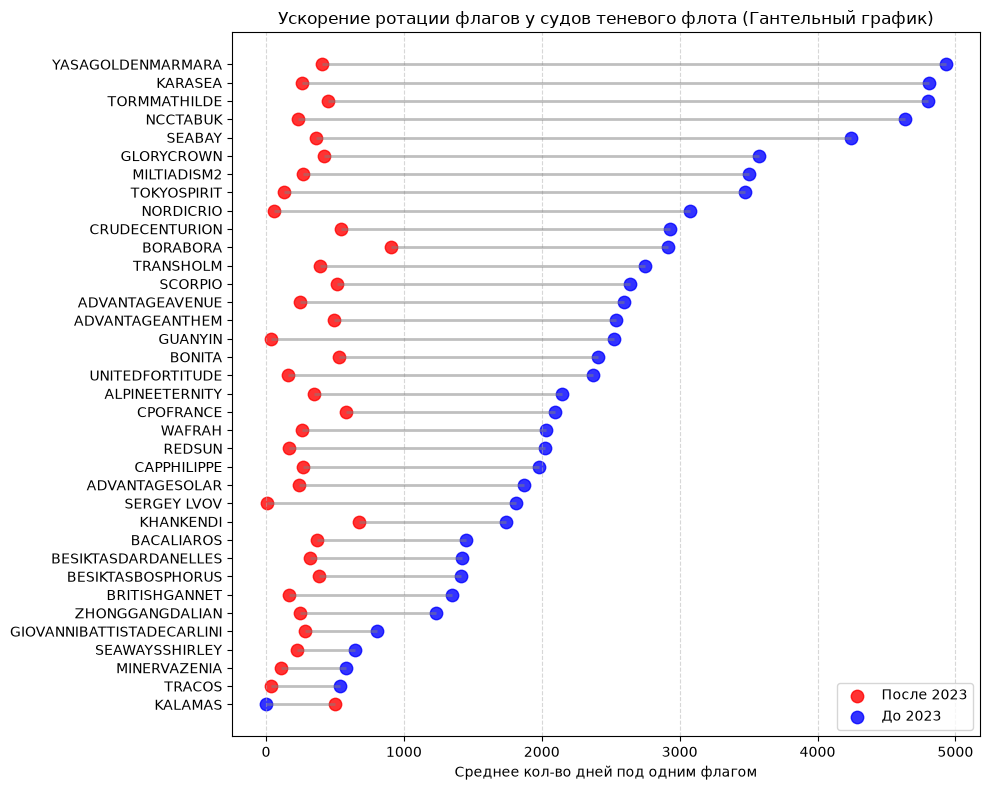

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Предполагаем, что identities_df и summary_df уже загружены

# 1. Подготовка данных: переводим даты и считаем длительность в днях
df = identities_df.copy()
df['transmission_from'] = pd.to_datetime(df['transmission_from'], format='mixed', utc=True)
df['transmission_to'] = pd.to_datetime(df['transmission_to'], format='mixed', utc=True)
# Если transmission_to нал, берем сегодняшнюю дату (или дату выгрузки данных)df['transmission_to'] = df['transmission_to'].fillna(pd.Timestamp.now(tz='UTC'))
df['duration_days'] = (df['transmission_to'] - df['transmission_from']).dt.days

# 2. Разделяем на периоды (до 2023 и после)
df['period'] = df['transmission_from'].apply(lambda x: 'before_2023' if x.year < 2023 else 'after_2023')

# 3. Считаем среднюю длительность владения флагом для каждого IMO в каждом периоде
grouped = df.groupby(['imo', 'period'])['duration_days'].mean().unstack()

# 4. Оставляем только те суда, у которых есть данные за оба периода и сбрасываем индекс, чтобы получить IMO как колонку
plot_data = grouped.dropna().reset_index()

# Присоединяем текущие имена судов для наглядности на оси Y
plot_data = plot_data.merge(summary_df[['imo', 'current_name']], on='imo')

# 5. Отрисовка Гантельного графика
plt.figure(figsize=(10, 8))
# Сортируем для красоты по длительности "до 2023"
plot_data = plot_data.sort_values('before_2023')

# Рисуем линии
plt.hlines(y=plot_data['current_name'], xmin=plot_data['after_2023'], xmax=plot_data['before_2023'], color='grey', alpha=0.5, linewidth=2)

# Рисуем точки
plt.scatter(plot_data['after_2023'], plot_data['current_name'], color='red', alpha=0.8, label='После 2023', s=80)
plt.scatter(plot_data['before_2023'], plot_data['current_name'], color='blue', alpha=0.8, label='До 2023', s=80)

plt.legend()
plt.xlabel('Среднее кол-во дней под одним флагом')
plt.title('Ускорение ротации флагов у судов теневого флота (Гантельный график)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()